## Price Prediction
Objective

Develop a machine learning model to predict the nightly price of Airbnb listings in Amsterdam based on listing characteristics, host information, location, and property features.

### Import Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)

### Load Dataset

In [74]:
from pathlib import Path

DATA_PATH = Path("../../Data/processed")
master = pd.read_parquet(DATA_PATH / "master_listings.parquet")
print(f"Rows    : {master.shape[0]:,}")
print(f"Columns : {master.shape[1]}")
master.head()


Rows    : 10,480
Columns : 120


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,property_type_normalized,host_tenure_years,price_per_bedroom,host_segment,city,_is_valid,review_count,latest_review_date,earliest_review_date,has_text_review_count,active_review_months,reviews_per_month_computed,total_days,booked_days,available_days,occupancy_rate,weekend_booked_days,weekend_total_days,weekday_booked_days,weekday_total_days,peak_month,weekend_occupancy_rate,weekday_occupancy_rate,review_frequency,estimated_annual_revenue_computed,price_tier,is_high_performer,days_since_last_review,neighbourhood_median_price,neighbourhood_mean_price,neighbourhood_min_price,neighbourhood_max_price,neighbourhood_price_std,neighbourhood_listing_count,neighbourhood_avg_rating,neighbourhood_avg_cleanliness,neighbourhood_avg_location,neighbourhood_avg_occupancy,neighbourhood_superhost_pct,neighbourhood_price_rank,price_vs_neighbourhood_median
0,27886,https://www.airbnb.com/rooms/27886,20250911031321,2025-09-11,city scrape,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,https://www.airbnb.com/users/show/97647,Flip,2010-03-23,"Amsterdam, Netherlands","Marjan works in ""eye"" the dutch filmmuseum, an...",within an hour,100.0,97.0,True,https://a0.muscache.com/im/users/97647/profile...,https://a0.muscache.com/im/users/97647/profile...,Westelijke Eilanden,1.0,1.0,"['email', 'phone']",True,True,"Amsterdam, North Holland, Netherlands",Centrum-West,,52.38761,4.89188,Private room in houseboat,Private room,2,1.5,1.5 baths,1.0,1.0,"[""Canal view"", ""Coffee"", ""Private backyard \u2...",132.0,3,356,3.0,3.0,30.0,30.0,3.0,30.0,,True,2,5,16,17,2025-09-11,311,33,3,17,26,255,33660.0,2012-01-09,2025-09-07,4.92,4.90,4.94,4.95,4.93,4.90,4.78,0363 974D 4986 7411 88D8,False,1,0,1,0,1.87,Other,16.26,132.0,Single-listing,Amsterdam,True,311.0,2025-09-07,2012-01-09,310.0,163.93,1.8972,365,348,17,0.9534,101,104,247,261,1.0,0.9712,0.9464,1.8972,45934.81,Mid-range (€81–€150),True,293.0,245.5,315.88,58.0,10000.0,429.96,1207,4.803,4.760,4.931,0.6762,31.3,2,-46.23
1,28871,https://www.airbnb.com/rooms/28871,20250911031321,2025-09-11,city scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,https://www.airbnb.com/users/show/124245,Edwin,2010-05-13,"Amsterdam, Netherlands",Hi,within an hour,100.0,99.0,True,https://a0.muscache.com/im/pictures/user/9986b...,https://a0.muscache.com/im/pictures/user/9986b...,Amst

In [55]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Columns: 120 entries, id to price_vs_neighbourhood_median
dtypes: Int64(1), bool(3), category(2), datetime64[ns](7), float64(48), int64(28), object(31)
memory usage: 9.3+ MB


In [56]:
master.describe().T

,count,mean,min,25%,50%,75%,max,std
id,10480.0,592546397015783936.0,27886.0,26293728.25,689347426246034560.0,1119610195817792000.0,1506287353709120512.0,562067488034233600.0
scrape_id,10480.0,20250911031321.0,20250911031321.0,20250911031321.0,20250911031321.0,20250911031321.0,20250911031321.0,0.0
last_scraped,10480,2025-09-11 00:00:00,2025-09-11 00:00:00,2025-09-11 00:00:00,2025-09-11 00:00:00,2025-09-11 00:00:00,2025-09-11 00:00:00,NaN
host_id,10480.0,134501911.112691,1662.0,12777805.25,45478429.5,187719627.75,717346955.0,180435871.998197
host_since,10477,2016-07-31 06:28:24.991887360,2008-08-11 00:00:00,2014-03-08 00:00:00,2015-10-09 00:00:00,2018-05-06 00:00:00,2025-09-05 00:00:00,NaN
...,...,...,...,...,...,...,...,...
neighbourhood_avg_location,10480.0,4.816578,4.469,4.751,4.844,4.885,4.931,0.0919
neighbourhood_avg_occupancy,10480.0,0.742327,0.6352,0.7165,0.758,0.7801,0.8168,0.052576
neighbourhood_superhost_pct,10480.0,17.771927,6.7,13.4,15.6,19.7,31.3,6.373817
neighbourhood_price_rank,10480.0,6.253435,1.0,3.0,5.0,10.0,22.0,4.962007


In [57]:
master.isna().mean()*100

id                                0.000000
listing_url                       0.000000
scrape_id                         0.000000
last_scraped                      0.000000
source                            0.000000
                                   ...    
neighbourhood_avg_location        0.000000
neighbourhood_avg_occupancy       0.000000
neighbourhood_superhost_pct       0.000000
neighbourhood_price_rank          0.000000
price_vs_neighbourhood_median    43.950382
Length: 120, dtype: float64

In [58]:
features = ['accommodates','bedrooms','bathrooms','beds','room_type','property_type','neighbourhood_cleansed',
            'availability_365','minimum_nights','number_of_reviews','review_scores_rating','host_is_superhost','instant_bookable','price']

master[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   accommodates            10480 non-null  int64  
 1   bedrooms                10174 non-null  float64
 2   bathrooms               10480 non-null  object 
 3   beds                    10480 non-null  float64
 4   room_type               10480 non-null  object 
 5   property_type           10480 non-null  object 
 6   neighbourhood_cleansed  10480 non-null  object 
 7   availability_365        10480 non-null  int64  
 8   minimum_nights          10480 non-null  int64  
 9   number_of_reviews       10480 non-null  int64  
 10  review_scores_rating    9383 non-null   float64
 11  host_is_superhost       10365 non-null  object 
 12  instant_bookable        10480 non-null  bool   
 13  price                   5874 non-null   float64
dtypes: bool(1), float64(4), int64(4), obje

### Select Features

In [59]:
df = master.copy()
df = df[
[
    "price",
    "room_type",
    "property_type",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "availability_365",
    "minimum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "host_is_superhost",
    "instant_bookable",
    "neighbourhood_cleansed"
]
]


In [60]:
print(df.shape)
df.head()

(10480, 14)


,price,room_type,property_type,accommodates,bedrooms,bathrooms,beds,availability_365,minimum_nights,number_of_reviews,review_scores_rating,host_is_superhost,instant_bookable,neighbourhood_cleansed
0,132.0,Private room,Private room in houseboat,2,1.0,1.5,1.0,17,3,311,4.92,True,False,Centrum-West
1,89.0,Private room,Private room in rental unit,2,1.0,1.0,1.0,126,2,732,4.87,True,False,Centrum-West
2,61.0,Private room,Private room in condo,2,1.0,1.0,1.0,95,2,849,4.81,True,False,Centrum-Oost
3,NaN,Entire home/apt,Entire rental unit,4,2.0,,2.0,0,3,42,4.71,False,False,Centrum-Oost
4,NaN,Entire home/apt,Entire rental unit,4,2.0,,2.0,0,3,5,5.00,False,False,Buitenveldert - Zuidas


### check null values

In [61]:
missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(2)
)

missing

price                     43.95
review_scores_rating      10.47
bedrooms                   2.92
host_is_superhost          1.10
room_type                  0.00
property_type              0.00
bathrooms                  0.00
accommodates               0.00
beds                       0.00
availability_365           0.00
number_of_reviews          0.00
minimum_nights             0.00
instant_bookable           0.00
neighbourhood_cleansed     0.00
dtype: float64

In [62]:
df.dtypes

price                     float64
room_type                  object
property_type              object
accommodates                int64
bedrooms                  float64
bathrooms                  object
beds                      float64
availability_365            int64
minimum_nights              int64
number_of_reviews           int64
review_scores_rating      float64
host_is_superhost          object
instant_bookable             bool
neighbourhood_cleansed     object
dtype: object

In [63]:
df["bathrooms"].unique()[:20]

array(['1.5', '1.0', '', '2.0', '2.5', '0.0', '3.0', '3.5', '4.0', '0.5',
       '5.0', '5.5', '12.0', '4.5', '17.0', '6.0'], dtype=object)

In [64]:
df["bathrooms"].value_counts().head(20)

bathrooms
        4548
1.0     3993
1.5     1293
2.0      341
2.5      113
3.0       66
0.0       57
0.5       29
3.5       20
4.0        5
5.5        5
5.0        4
4.5        3
12.0       1
17.0       1
6.0        1
Name: count, dtype: int64

### Prepair null prices

In [65]:
df = df.dropna(subset=["price"])

In [66]:
df["review_scores_rating"] = df["review_scores_rating"].fillna(
    df["review_scores_rating"].median()
)

In [67]:
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

In [68]:
df['host_is_superhost']= df['host_is_superhost'].fillna(df['host_is_superhost'].mode())

### convert data type

In [69]:

def to_tf_string(series):
    """
    Convert any boolean-like column to consistent 't'/'f' strings.
    Handles: True/False booleans, 1/0 integers, 't'/'f' strings.
    """
    return series.map({
        True: 't', False: 'f',
        1: 't', 0: 'f',
        1.0: 't', 0.0: 'f',
        't': 't', 'f': 'f',
    })

for col in ['host_is_superhost', 'instant_bookable']:
    if col in df.columns:
        before_unique = df[col].unique()[:5].tolist()
        df[col] = to_tf_string(df[col])
        after_unique  = df[col].unique()[:5].tolist()
        null_after    = df[col].isna().sum()
        print(f'{col}: {before_unique} -> {after_unique}  (nulls after: {null_after})')

# Drop any rows where the mapping produced NaN (unexpected values)
before = len(df)
df     = df.dropna(subset=['host_is_superhost', 'instant_bookable'])
if before - len(df) > 0:
    print(f'Dropped {before - len(df)} rows with unmappable boolean values')

host_is_superhost: [True, False, nan] -> ['t', 'f', nan]  (nulls after: 59)
instant_bookable: [False, True] -> ['f', 't']  (nulls after: 0)
Dropped 59 rows with unmappable boolean values


In [70]:
df[['host_is_superhost', 'instant_bookable']].head(10)

,host_is_superhost,instant_bookable
0,t,f
1,t,f
2,t,f
5,t,f
6,f,f
7,f,f
8,t,f
15,f,f
16,t,f
21,t,f


In [71]:
print(df.isnull().sum())
df.dtypes

price                     0
room_type                 0
property_type             0
accommodates              0
bedrooms                  0
bathrooms                 0
beds                      0
availability_365          0
minimum_nights            0
number_of_reviews         0
review_scores_rating      0
host_is_superhost         0
instant_bookable          0
neighbourhood_cleansed    0
dtype: int64


price                     float64
room_type                  object
property_type              object
accommodates                int64
bedrooms                  float64
bathrooms                  object
beds                      float64
availability_365            int64
minimum_nights              int64
number_of_reviews           int64
review_scores_rating      float64
host_is_superhost          object
instant_bookable           object
neighbourhood_cleansed     object
dtype: object

C:\Users\Asus\AppData\Local\Temp\ipykernel_19036\2742982681.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(room_counts.index, rotation=15, ha='right', fontsize=9)


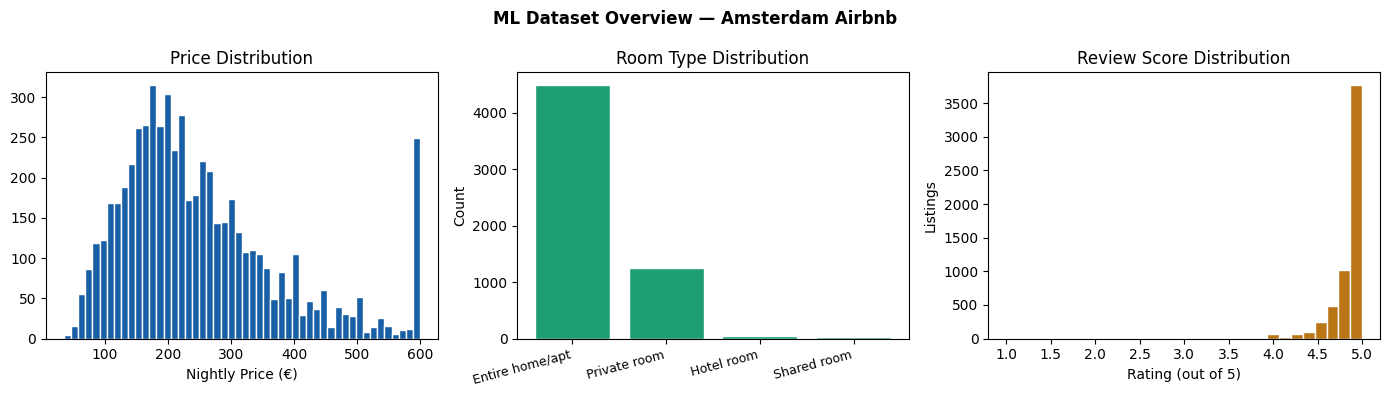


Dataset summary:
  Total listings      : 5,815
  Entire home/apt     : 4,493
  Private room        : 1,254
  Superhost listings  : 1,496
  Instant bookable    : 1,074


In [81]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('ML Dataset Overview — Amsterdam Airbnb', fontweight='bold')

# Price distribution
axes[0].hist(df['price'].clip(upper=600), bins=50,
             color='#185FA5', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Nightly Price (€)')


# Room type counts
room_counts = df['room_type'].value_counts()
axes[1].bar(room_counts.index, room_counts.values,
            color='#1D9E75', edgecolor='white')
axes[1].set_title('Room Type Distribution')
axes[1].set_xticklabels(room_counts.index, rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('Count')

# Review score distribution
axes[2].hist(df['review_scores_rating'], bins=30,
             color='#BA7517', edgecolor='white')
axes[2].set_title('Review Score Distribution')
axes[2].set_xlabel('Rating (out of 5)')
axes[2].set_ylabel('Listings')

plt.tight_layout()
plt.savefig('../../reports/fig_ml_data_overview.png',
            dpi=130, bbox_inches='tight')
plt.show()

print('\nDataset summary:')
print(f'  Total listings      : {len(df):,}')
print(f'  Entire home/apt     : {(df["room_type"]=="Entire home/apt").sum():,}')
print(f'  Private room        : {(df["room_type"]=="Private room").sum():,}')
print(f'  Superhost listings  : {(df["host_is_superhost"]=="t").sum():,}')
print(f'  Instant bookable    : {(df["instant_bookable"]=="t").sum():,}')

In [77]:
# Save for notebook 02 — Feature Engineering
save_path = r'D:\Expernetic\airbnb-data-engineering-pipeline\Data\processed\ml_prepared.parquet'
df.to_parquet(save_path, index=False)
print(f'Saved to: {save_path}')
print(f'Shape   : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'\nColumns saved:')
for col in df.columns:
    print(f'  {col:<30}: {df[col].dtype}')
print('\nNotebook 01 complete. Run 02_Feature_Engineering.ipynb next.')

Saved to: D:\Expernetic\airbnb-data-engineering-pipeline\Data\processed\ml_prepared.parquet
Shape   : 5,815 rows x 14 columns

Columns saved:
  price                         : float64
  room_type                     : object
  property_type                 : object
  accommodates                  : int64
  bedrooms                      : float64
  bathrooms                     : object
  beds                          : float64
  availability_365              : int64
  minimum_nights                : int64
  number_of_reviews             : int64
  review_scores_rating          : float64
  host_is_superhost             : object
  instant_bookable              : object
  neighbourhood_cleansed        : object

Notebook 01 complete. Run 02_Feature_Engineering.ipynb next.
